# Network Anomaly Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Dark theme rcParams
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#16213e',
    'legend.facecolor': '#16213e',
    'legend.edgecolor': 'white',
    'legend.labelcolor': 'white',
    'figure.figsize': (12, 6),
    'font.size': 12
})

# Load data
households = pd.read_csv('../data/households.csv')
events = pd.read_csv('../data/network_events.csv')

print(f"Households: {households.shape}")
print(f"Network events: {events.shape}")
print(f"\nHouseholds columns: {list(households.columns)}")
print(f"Events columns: {list(events.columns)}")

/Users/harthikmallichetty/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Households: (5000, 10)
Network events: (450000, 7)

Households columns: ['household_id', 'device_model', 'firmware_version', 'plan_type', 'region', 'num_nodes', 'connected_devices', 'tenure_days', 'signup_date', 'churned']
Events columns: ['household_id', 'date', 'connection_drops', 'avg_latency_ms', 'peak_bandwidth_mbps', 'offline_duration_minutes', 'packet_loss_pct']


## Feature Engineering for Anomaly Detection

In [2]:
# Compute per-household aggregate features from network events
agg_features = events.groupby('household_id').agg(
    avg_drops=('connection_drops', 'mean'),
    avg_latency=('avg_latency_ms', 'mean'),
    avg_offline=('offline_duration_minutes', 'mean'),
    avg_packet_loss=('packet_loss_pct', 'mean'),
    drops_std=('connection_drops', 'std'),
    offline_max=('offline_duration_minutes', 'max')
).reset_index()

# Fill NaN std (households with single event) with 0
agg_features['drops_std'] = agg_features['drops_std'].fillna(0)

# Compute latency_trend: max week-over-week % change in weekly avg latency
events['date'] = pd.to_datetime(events['date'])
events['week'] = events['date'].dt.isocalendar().week.astype(int)
events['year_week'] = events['date'].dt.strftime('%Y-%U')

weekly_latency = events.groupby(['household_id', 'year_week'])['avg_latency_ms'].mean().reset_index()
weekly_latency = weekly_latency.sort_values(['household_id', 'year_week'])

def max_wow_pct_change(group):
    """Compute max week-over-week % change in latency."""
    vals = group['avg_latency_ms'].values
    if len(vals) < 2:
        return 0.0
    pct_changes = []
    for i in range(1, len(vals)):
        if vals[i - 1] > 0:
            pct_changes.append(abs((vals[i] - vals[i - 1]) / vals[i - 1]) * 100)
    return max(pct_changes) if pct_changes else 0.0

latency_trend = weekly_latency.groupby('household_id').apply(max_wow_pct_change).reset_index()
latency_trend.columns = ['household_id', 'latency_trend']

# Merge all features
features = agg_features.merge(latency_trend, on='household_id', how='left')
features['latency_trend'] = features['latency_trend'].fillna(0)

# Merge with households to get churned column
features = features.merge(households[['household_id', 'churned']], on='household_id', how='left')

print(f"Feature matrix shape: {features.shape}")
print(f"\nFeature columns: {list(features.columns)}")
print(f"\nSample data:")
features.head()

Feature matrix shape: (5000, 9)

Feature columns: ['household_id', 'avg_drops', 'avg_latency', 'avg_offline', 'avg_packet_loss', 'drops_std', 'offline_max', 'latency_trend', 'churned']

Sample data:


/var/folders/q9/n6jr7hp93779mb33t9dsgn5m0000gn/T/ipykernel_41114/3688902003.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  latency_trend = weekly_latency.groupby('household_id').apply(max_wow_pct_change).reset_index()


,household_id,avg_drops,avg_latency,avg_offline,avg_packet_loss,drops_std,offline_max,latency_trend,churned
0,HH-00000,5.033333,36.921111,7.007778,1.354600,2.300220,36.3,43.780254,1
1,HH-00001,2.444444,40.183333,4.070000,0.884400,1.622255,19.7,70.332681,0
2,HH-00002,2.688889,21.354444,4.927778,0.853289,1.752330,17.0,181.755196,0
3,HH-00003,3.177778,29.416667,4.047778,0.768400,1.814906,14.3,80.653951,0
4,HH-00004,2.522222,21.395556,4.115556,0.816478,1.623063,29.8,139.824561,0


## Isolation Forest Model

In [3]:
# Define feature columns for the model
feature_cols = ['avg_drops', 'avg_latency', 'avg_offline', 'avg_packet_loss',
                'drops_std', 'latency_trend', 'offline_max']

X = features[feature_cols].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=200
)
iso_forest.fit(X_scaled)

# Get anomaly scores and labels
features['anomaly_score'] = iso_forest.decision_function(X_scaled)
features['is_anomaly'] = iso_forest.predict(X_scaled)
# Convert labels: -1 = anomaly, 1 = normal
features['is_anomaly'] = (features['is_anomaly'] == -1).astype(int)

n_anomalies = features['is_anomaly'].sum()
n_total = len(features)
print(f"Total households analyzed: {n_total}")
print(f"Anomalies flagged: {n_anomalies} ({n_anomalies/n_total*100:.1f}%)")
print(f"Normal households: {n_total - n_anomalies} ({(n_total - n_anomalies)/n_total*100:.1f}%)")

Total households analyzed: 5000
Anomalies flagged: 250 (5.0%)
Normal households: 4750 (95.0%)


## Cross-Validation: Anomaly vs Actual Churn

Churn rate in ANOMALY group: 93.6%
Churn rate in NORMAL group:  7.8%
Lift (anomaly / normal):     11.95x


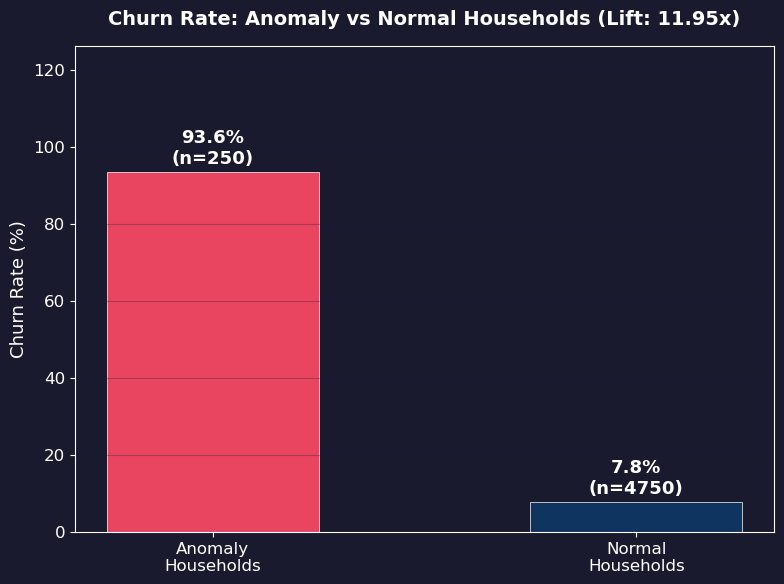

In [4]:
# Compare churn rates between anomaly and normal groups
anomaly_group = features[features['is_anomaly'] == 1]
normal_group = features[features['is_anomaly'] == 0]

churn_rate_anomaly = anomaly_group['churned'].mean() * 100
churn_rate_normal = normal_group['churned'].mean() * 100
lift = churn_rate_anomaly / churn_rate_normal if churn_rate_normal > 0 else float('inf')

print(f"Churn rate in ANOMALY group: {churn_rate_anomaly:.1f}%")
print(f"Churn rate in NORMAL group:  {churn_rate_normal:.1f}%")
print(f"Lift (anomaly / normal):     {lift:.2f}x")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(8, 6))

groups = ['Anomaly\nHouseholds', 'Normal\nHouseholds']
churn_rates = [churn_rate_anomaly, churn_rate_normal]
counts = [len(anomaly_group), len(normal_group)]

bars = ax.bar(groups, churn_rates, color=['#e94560', '#0f3460'], edgecolor='white', linewidth=0.5, width=0.5)

# Add value labels on bars
for bar, rate, count in zip(bars, churn_rates, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{rate:.1f}%\n(n={count})', ha='center', va='bottom',
            fontweight='bold', color='white', fontsize=13)

ax.set_ylabel('Churn Rate (%)', fontsize=13)
ax.set_title(f'Churn Rate: Anomaly vs Normal Households (Lift: {lift:.2f}x)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(churn_rates) * 1.35)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/anomaly_churn_comparison.png', dpi=300, facecolor='#1a1a2e', bbox_inches='tight')
plt.show()

## Anomaly Score Distribution

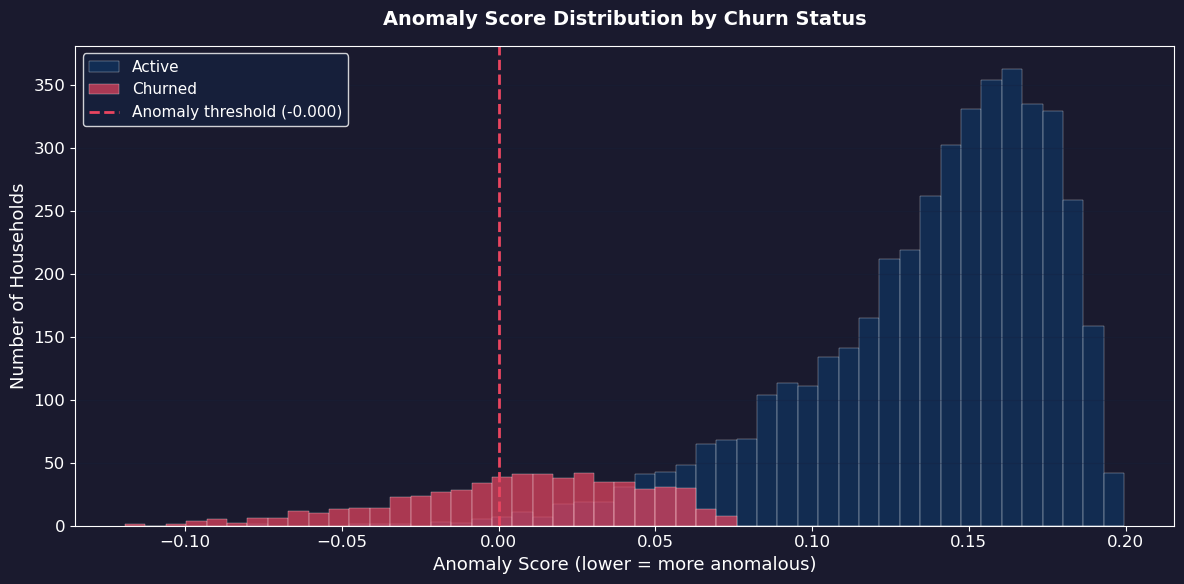

Anomaly score range: [-0.1192, 0.1995]
Anomaly threshold (max score for flagged anomalies): -0.0000


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram of anomaly scores colored by churn status
churned_scores = features[features['churned'] == 1]['anomaly_score']
active_scores = features[features['churned'] == 0]['anomaly_score']

bins = np.linspace(features['anomaly_score'].min(), features['anomaly_score'].max(), 50)

ax.hist(active_scores, bins=bins, alpha=0.7, label='Active', color='#0f3460', edgecolor='white', linewidth=0.3)
ax.hist(churned_scores, bins=bins, alpha=0.7, label='Churned', color='#e94560', edgecolor='white', linewidth=0.3)

# Add threshold line for anomaly cutoff
threshold = features[features['is_anomaly'] == 1]['anomaly_score'].max()
ax.axvline(x=threshold, color='#e94560', linestyle='--', linewidth=2, label=f'Anomaly threshold ({threshold:.3f})')

ax.set_xlabel('Anomaly Score (lower = more anomalous)', fontsize=13)
ax.set_ylabel('Number of Households', fontsize=13)
ax.set_title('Anomaly Score Distribution by Churn Status', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/anomaly_vs_churn.png', dpi=300, facecolor='#1a1a2e', bbox_inches='tight')
plt.show()

print(f"Anomaly score range: [{features['anomaly_score'].min():.4f}, {features['anomaly_score'].max():.4f}]")
print(f"Anomaly threshold (max score for flagged anomalies): {threshold:.4f}")

## Top At-Risk Households

In [6]:
# Show top 20 most anomalous households (lowest anomaly score = most anomalous)
top_anomalies = features.nsmallest(20, 'anomaly_score')[
    ['household_id', 'avg_drops', 'avg_latency', 'avg_offline', 'avg_packet_loss',
     'drops_std', 'latency_trend', 'offline_max', 'anomaly_score', 'churned']
].copy()

# Format for display
top_anomalies['churned'] = top_anomalies['churned'].map({1: 'Yes', 0: 'No'})
top_anomalies = top_anomalies.rename(columns={
    'household_id': 'Household',
    'avg_drops': 'Avg Drops',
    'avg_latency': 'Avg Latency (ms)',
    'avg_offline': 'Avg Offline (min)',
    'avg_packet_loss': 'Avg Pkt Loss (%)',
    'drops_std': 'Drops StdDev',
    'latency_trend': 'Latency Trend (%)',
    'offline_max': 'Max Offline (min)',
    'anomaly_score': 'Anomaly Score',
    'churned': 'Churned'
})

# Round numeric columns
numeric_cols = ['Avg Drops', 'Avg Latency (ms)', 'Avg Offline (min)', 'Avg Pkt Loss (%)',
                'Drops StdDev', 'Latency Trend (%)', 'Max Offline (min)', 'Anomaly Score']
for col in numeric_cols:
    top_anomalies[col] = top_anomalies[col].round(2)

top_anomalies = top_anomalies.reset_index(drop=True)
top_anomalies.index = top_anomalies.index + 1
top_anomalies.index.name = 'Rank'

print("Top 20 Most Anomalous Households")
print("=" * 80)
top_anomalies

Top 20 Most Anomalous Households


,Household,Avg Drops,Avg Latency (ms),Avg Offline (min),Avg Pkt Loss (%),Drops StdDev,Latency Trend (%),Max Offline (min),Anomaly Score,Churned
Rank,,,,,,,,,,
1,HH-01612,5.27,48.52,7.86,1.36,2.72,26.73,46.4,-0.12,Yes
2,HH-01068,4.20,58.07,8.07,1.40,2.13,34.98,58.0,-0.10,Yes
3,HH-01728,5.03,50.30,9.29,1.23,2.38,35.90,44.2,-0.10,Yes
4,HH-03297,5.56,36.86,8.18,1.26,2.28,56.63,67.7,-0.10,Yes
5,HH-04849,6.50,28.87,5.97,1.30,2.97,248.07,27.8,-0.10,Yes
6,HH-04678,6.39,27.12,5.71,1.25,2.64,253.43,32.3,-0.09,Yes
7,HH-02742,5.43,31.57,8.40,1.28,2.47,152.59,39.0,-0.09,Yes
8,HH-02580,5.92,26.61,8.72,1.23,2.48,95.23,38.7,-0.09,Yes
9,HH-03288,4.81,38.07,6.78,1.32,1.99,589.33,40.6,-0.09,Yes


## Key Findings

In [7]:
# Summary statistics
total_anomalies = features['is_anomaly'].sum()
total_households = len(features)

# Churn rate lift
churn_rate_anomaly = features[features['is_anomaly'] == 1]['churned'].mean() * 100
churn_rate_normal = features[features['is_anomaly'] == 0]['churned'].mean() * 100
lift = churn_rate_anomaly / churn_rate_normal if churn_rate_normal > 0 else float('inf')

# Precision: of those flagged as anomalies, how many actually churned?
true_positives = features[(features['is_anomaly'] == 1) & (features['churned'] == 1)].shape[0]
false_positives = features[(features['is_anomaly'] == 1) & (features['churned'] == 0)].shape[0]
precision = true_positives / (true_positives + false_positives) * 100 if (true_positives + false_positives) > 0 else 0

# Recall: of those who churned, how many were flagged as anomalies?
total_churned = features['churned'].sum()
recall = true_positives / total_churned * 100 if total_churned > 0 else 0

print("=" * 60)
print("  ANOMALY DETECTION — KEY FINDINGS")
print("=" * 60)
print(f"")
print(f"  Total households analyzed:    {total_households}")
print(f"  Anomalies flagged:            {total_anomalies} ({total_anomalies/total_households*100:.1f}%)")
print(f"")
print(f"  Churn rate (anomaly group):   {churn_rate_anomaly:.1f}%")
print(f"  Churn rate (normal group):    {churn_rate_normal:.1f}%")
print(f"  Churn rate lift:              {lift:.2f}x")
print(f"")
print(f"  Precision (anomaly → churn):  {precision:.1f}%")
print(f"  Recall (churn → anomaly):     {recall:.1f}%")
print(f"")
print(f"  True positives (anomaly & churned):  {true_positives}")
print(f"  False positives (anomaly & active):  {false_positives}")
print(f"")
print("=" * 60)
print(f"  Anomalous households churn at {lift:.2f}x the rate of")
print(f"  normal households, validating network quality as a")
print(f"  leading indicator of customer churn.")
print("=" * 60)

  ANOMALY DETECTION — KEY FINDINGS

  Total households analyzed:    5000
  Anomalies flagged:            250 (5.0%)

  Churn rate (anomaly group):   93.6%
  Churn rate (normal group):    7.8%
  Churn rate lift:              11.95x

  Precision (anomaly → churn):  93.6%
  Recall (churn → anomaly):     38.6%

  True positives (anomaly & churned):  234
  False positives (anomaly & active):  16

  Anomalous households churn at 11.95x the rate of
  normal households, validating network quality as a
  leading indicator of customer churn.
